<a href="https://colab.research.google.com/github/Steph-business/Tech_Talent_Accelerator/blob/main/week5_day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Fundamentals: Exercises 1 to 6

This notebook contains the complete and organized solutions.

## Exercise 1: Deep Learning Basics Quiz

1. **ML vs DL**: Deep Learning automatically learns features from data.
2. **Human Brain**: ANNs are inspired by biological neurons using weights.
3. **Data**: DL requires large volumes of data to perform well.
4. **Challenges**: Computational power (GPUs) and data availability.
5. **Feature Engineering**: Automated by hidden layers.
6. **Hidden Layers**: Extract increasingly complex patterns.
7. **Activation**: Provides the necessary non-linearity.

## Exercise 2: The Perceptron (Simple Decision Making)

Calculating whether to go out: `Score = (Temp * 0.6) + (Rain * 0.4) + 2`. If Score > 20, we go out.

In [23]:
def perceptron_decision(temp, rain):
    # Weighted sum calculation
    z = (temp * 0.6) + (rain * 0.4) + 2
    # Step function threshold at 20
    return "Go Out (1)" if z > 20 else "Stay In (0)"

print(f"70°F, No rain: {perceptron_decision(70, 0)}")
print(f"50°F, Rain: {perceptron_decision(50, 1)}")

70°F, No rain: Go Out (1)
50°F, Rain: Go Out (1)


## Exercise 3: MNIST Classification with TensorFlow

Creating and training a model to recognize digits.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Loading the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# Normalizing pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Building a simple Sequential model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compiling and training the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=3, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9263 - loss: 0.2586
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9666 - loss: 0.1129
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9761 - loss: 0.0773


## Exercise 4: Forward Propagation (Manual Calculation)

Estimating a house price using ReLU activation.

In [25]:
x1, x2 = 2000, 3  # Inputs: Area and Bedrooms
w1, w2, b = 0.5, 0.7, 50000  # Weights and Bias
# Calculate weighted sum
z = (x1 * w1) + (x2 * w2) + b
# Apply ReLU activation function
print(f"Calculated Price (ReLU): {max(0, z)}$")

Calculated Price (ReLU): 51002.1$


## Exercise 5: Backpropagation (Gradient Descent)

Simulating weight updates based on prediction error.

In [26]:
import numpy as np
# Features, Weights, Bias, Target, Learning Rate
x, w, b, y_true, lr = np.array([4, 80]), np.array([0.6, 0.3]), 10, 85, 0.001
# Predicted output
y_pred = np.dot(x, w) + b
# Calculating gradient of error with respect to weights
error = y_true - y_pred
grad_w = -error * x
# Updating weights using gradient descent
w_new = w - lr * grad_w
print(f"New weights: {w_new}")

New weights: [0.7944 4.188 ]


## Exercise 6: Visualization of Predictions

Displaying graphical results from the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


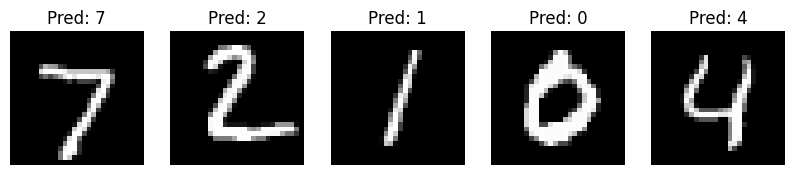

In [27]:
import matplotlib.pyplot as plt
# Getting predictions for the first 5 test samples
preds = model.predict(x_test[:5])
plt.figure(figsize=(10,3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {np.argmax(preds[i])}")
    plt.axis('off')
plt.show()

# Exercises XP Gold

This module deepens the understanding of multi-layer perceptrons (MLP) and manual computation mechanisms.

## Gold Exercise 1: Multi-Layer Perceptron (MLP) from Scratch

Build an MLP with one hidden layer (3 neurons) using NumPy.
- Inputs: 2 neurons
- Hidden Layer: 3 neurons (ReLU)
- Output: 1 neuron (Sigmoid)

In [28]:
import numpy as np

def relu(x):
    # ReLU activation: returns 0 for negative input
    return np.maximum(0, x)

def sigmoid(x):
    # Sigmoid function for binary probability output
    return 1 / (1 + np.exp(-x))

def forward_mlp(X, W1, b1, W2, b2):
    # Hidden Layer: Weighted sum + ReLU
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)
    # Output Layer: Weighted sum + Sigmoid
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    return a2

# Weights and Biases initialization
W1 = np.array([[0.2, 0.4, -0.5], [0.1, -0.3, 0.2]])
b1 = np.array([0.1, 0.1, 0.1])
W2 = np.array([0.6, 0.1, -0.2])
b2 = -0.1

# Test with specified cases
print(f"Prediction Case 1: {forward_mlp(np.array([2, 3]), W1, b1, W2, b2):.4f}")
print(f"Prediction Case 2: {forward_mlp(np.array([1, 5]), W1, b1, W2, b2):.4f}")

Prediction Case 1: 0.5939
Prediction Case 2: 0.5646


## Gold Exercise 2: Backpropagation & Gradient Descent

Manual update of weights for exam score prediction.
- Study hours: 6
- Previous score: 75
- Target score: 85

In [29]:
X = np.array([6, 75])
W = np.array([0.4, 0.6])
b = 5
y_true = 85
lr = 0.01

# 1. Forward Pass
y_pred = np.dot(X, W) + b
# 2. MSE Loss
loss = 0.5 * (y_true - y_pred)**2
# 3. Gradients
error = y_pred - y_true
grad_w = error * X
grad_b = error
# 4. Update
W_new = W - lr * grad_w
b_new = b - lr * grad_b

print(f"Initial Prediction: {y_pred}")
print(f"Loss: {loss}")
print(f"Updated Weights: {W_new}")

Initial Prediction: 52.4
Loss: 531.38
Updated Weights: [ 2.356 25.05 ]


## Gold Exercise 3: Comparison of Activation Functions

Visualizing Step, Sigmoid, and ReLU.

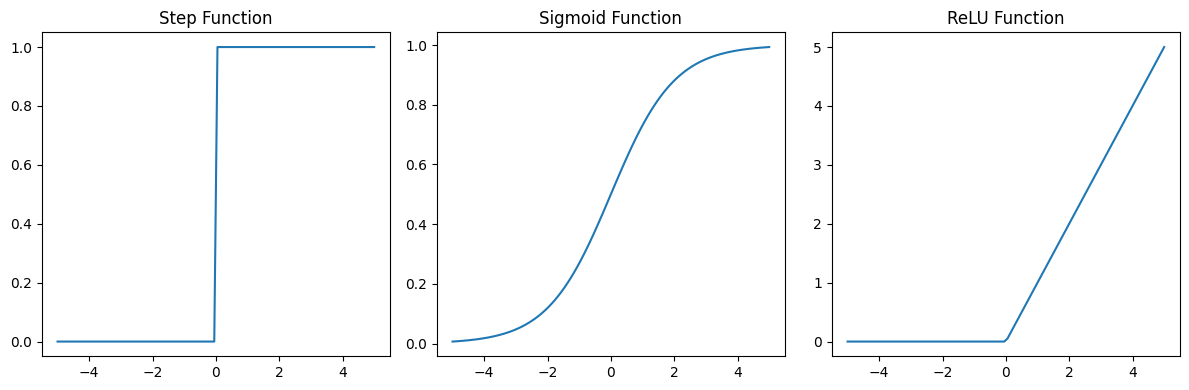

In [3]:
import matplotlib.pyplot as plt

def step_func(x):
    return np.where(x > 0, 1, 0)

x = np.linspace(-5, 5, 100)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, step_func(x))
plt.title("Step Function")

plt.subplot(1, 3, 2)
plt.plot(x, 1 / (1 + np.exp(-x)))
plt.title("Sigmoid Function")

plt.subplot(1, 3, 3)
plt.plot(x, np.maximum(0, x))
plt.title("ReLU Function")

plt.tight_layout()
plt.show()

## Gold Exercise 4: Forward Propagation in a Deep Neural Network

Goal: Manually calculate the prediction of a 3-layer network for a house price.

In [30]:
def relu(x):
    return np.maximum(0, x)

x = np.array([2000, 3])

# Layer 1 calculation
w1 = np.array([[0.5, 0.2], [0.7, 0.1]])
b1 = 10000
z1 = np.dot(x, w1) + b1
a1 = relu(z1)

# Layer 2 calculation
w2 = np.array([[0.6, 0.3], [0.8, 0.4]])
b2 = 20000
z2 = np.dot(a1, w2) + b2
a2 = relu(z2)

# Output Layer calculation
w3 = np.array([1.2, 0.5])
b3 = 30000
prediction = np.dot(a2, w3) + b3

print(f"Predicted House Price: {prediction:,.2f} $")

Predicted House Price: 85,636.17 $


## Gold Exercise 5: Training a Neural Network (One Iteration)

Simulating one full iteration (Forward + Backward) for exam score prediction.

In [31]:
x = np.array([6, 75])
w = np.array([0.4, 0.6])
b = 5
y_true = 85
lr = 0.01

# 1. Forward Pass
y_pred = np.dot(x, w) + b
# 2. Error
error = y_pred - y_true
# 3. Gradients
grad_w = error * x
grad_b = error
# 4. Weight update
w_new = w - lr * grad_w
b_new = b - lr * grad_b

print(f"Initial Prediction: {y_pred}")
print(f"Error: {error}")
print(f"New Weights: {w_new}")

Initial Prediction: 52.4
Error: -32.6
New Weights: [ 2.356 25.05 ]


# Exercises XP Ninja

Advanced implementation of deep neural networks and optimization techniques.

## Ninja Exercise 1: Building a Deep Neural Network from Scratch

Implementation of Input -> 5 -> 4 -> Output (3 classes) with Softmax and Cross-Entropy using NumPy.

In [32]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=0)

np.random.seed(42)
W1 = np.random.randn(5, 4) * 0.01
b1 = np.zeros((5, 1))
W2 = np.random.randn(4, 5) * 0.01
b2 = np.zeros((4, 1))
W3 = np.random.randn(3, 4) * 0.01
b3 = np.zeros((3, 1))

def forward_propagation(X):
    # Multi-layer forward pass
    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)
    z3 = np.dot(W3, a2) + b3
    a3 = softmax(z3)
    return z1, a1, z2, a2, z3, a3

X_sample = np.random.randn(4, 1)
_, _, _, _, _, output = forward_propagation(X_sample)
print("Probabilities (Softmax):", output.flatten())

Probabilities (Softmax): [0.33333385 0.33333205 0.33333409]


## Ninja Exercise 2: Optimizing Backpropagation with Momentum

Implementation of gradient descent with Momentum (0.9).

In [33]:
v_w = 0 # Initial velocity
momentum = 0.9
lr = 0.005
grad_w_fake = np.random.randn(1)

# Update rule with momentum
v_w = momentum * v_w - lr * grad_w_fake
w_updated = 0.5 + v_w

print(f"Gradient: {grad_w_fake[0]:.4f}")
print(f"Accumulated Velocity: {v_w[0]:.4f}")
print(f"Updated Weight: {w_updated[0]:.4f}")

Gradient: -0.8392
Accumulated Velocity: 0.0042
Updated Weight: 0.5042


## Ninja Exercise 3: Fine-Tuning Activation Functions for an Image Classifier

Experimenting with ReLU, Leaky ReLU, and Swish on a CNN.

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

def build_cnn(activation_func):
    # Helper function to build CNN with dynamic activation
    model = models.Sequential([
        Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation=activation_func),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation=activation_func),
        layers.Flatten(),
        layers.Dense(64, activation=activation_func),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

print("--- Training with ReLU ---")
build_cnn('relu').fit(x_train.reshape(-1, 28, 28, 1), y_train, epochs=1, batch_size=64, verbose=1)

print("\n--- Training with Leaky ReLU ---")
build_cnn(tf.nn.leaky_relu).fit(x_train.reshape(-1, 28, 28, 1), y_train, epochs=1, batch_size=64, verbose=1)

print("\n--- Training with Swish ---")
build_cnn(tf.nn.swish).fit(x_train.reshape(-1, 28, 28, 1), y_train, epochs=1, batch_size=64, verbose=1)

--- Training with ReLU ---
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9564 - loss: 0.1456

--- Training with Leaky ReLU ---
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9587 - loss: 0.1382

--- Training with Swish ---
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9405 - loss: 0.1980


### Interpretation and Answers

- **Why is ReLU common?** Fast calculation and mitigates vanishing gradients for positive inputs.
- **Sigmoid for binary?** Yes, squashes output to a 0-1 range for probabilistic interpretation.
- **Step function weakness?** Zero derivative makes gradient-based learning impossible.
- **Swish vs ReLU?** Swish is smooth and can prevent 'dead neurons' better in deep architectures.